# ABC Manufacturing Employee Attrition Analysis

## Initial Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load the Data Set

In [2]:
data = pd.read_csv('../data/raw/abc_employee_attrition.csv')


## Visualization of Variables

### Department Visualization: Bar Chart 1 - Workforce Composition

In [3]:
data['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

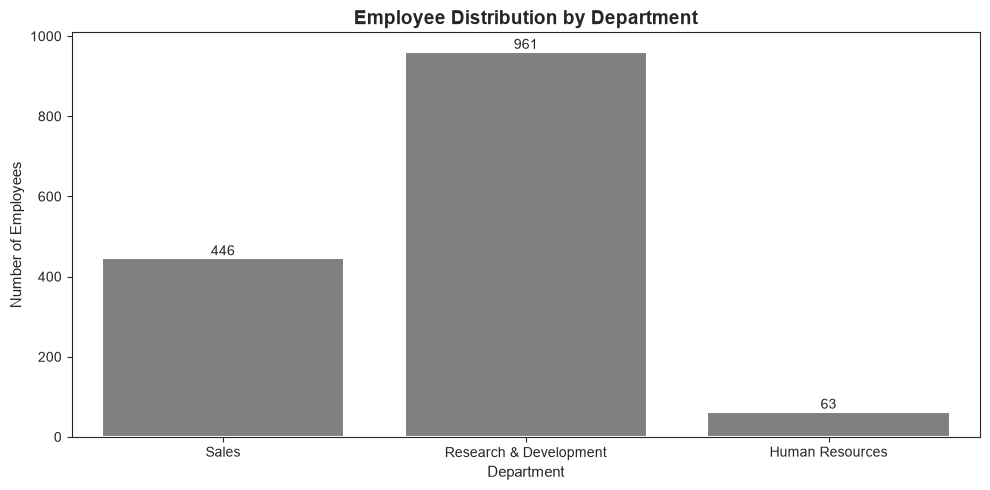

In [4]:
sns.set_style('ticks')

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data = data,
    x = 'Department',
    color = 'grey',
    linewidth = 1.5
)

plt.title('Employee Distribution by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=11)
plt.ylabel('Number of Employees', fontsize=11)

plt.xticks(rotation=0)
plt.bar_label(ax.containers[0])
plt.tight_layout()

plt.show()

Research & Development represents the largest proportion of the workforce, with 961 employees, followed by Sales with 446 employees. Human Resources represents the smallest departmental group, with 63 employees. This indicates that the workforce is unevenly distributed across departments, with Research & Development accounting for the majority of employees.

### JobRole Visualization: Bar Chart 2 - Workforce Composition by rate

In [5]:
data['JobRole'].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

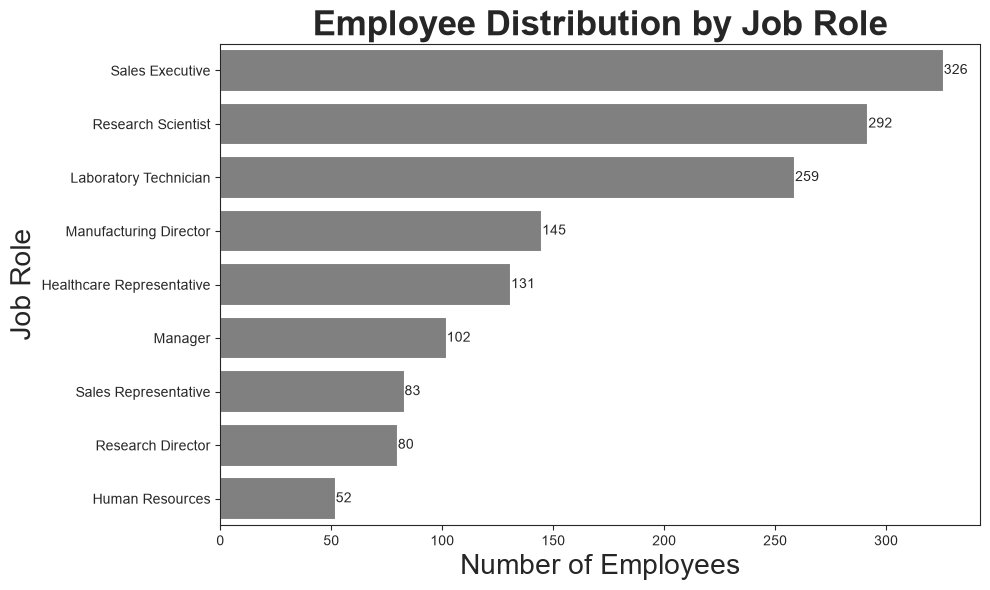

In [6]:
sns.set_style('ticks')

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data = data,
    y = 'JobRole',
    color = 'grey',
    linewidth = 1.5
)

plt.title('Employee Distribution by Job Role', fontsize=25, fontweight='bold')
plt.xlabel('Number of Employees', fontsize=20)
plt.ylabel('Job Role', fontsize=20)

plt.xticks(rotation=0)
plt.bar_label(ax.containers[0])
plt.tight_layout()

plt.show()

The distribution of employees across job roles is uneven. Sales Executive has the largest representation with 326 employees, followed by Research Scientist with 292 and Laboratory Technician with 259. Human Resources has the smallest representation with 52 employees. The results indicate that the workforce is concentrated within a few job roles, particularly Sales Executive, Research Scientist, and Laboratory Technician.

Although the chart identifies differences in workforce size across job roles, it does not establish which roles experience the highest attrition. Further comparison of JobRole against Attrition will be required to determine whether attrition rates differ between roles.

### OverTime Visualization: Bar Chart 3 - Workforce overtime distribution

In [7]:
data['OverTime'].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

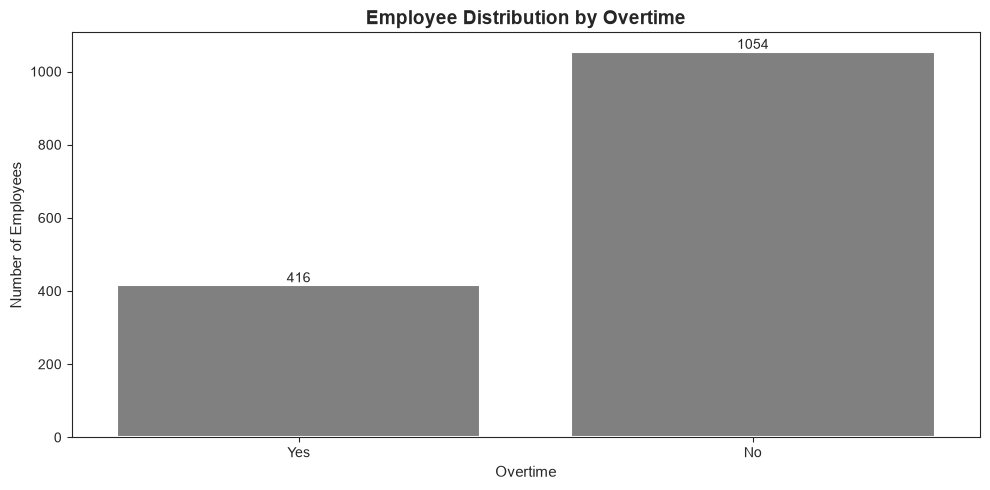

In [8]:
sns.set_style('ticks')

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data = data,
    x = 'OverTime',
    color = 'grey',
    linewidth = 1.5
)

plt.title('Employee Distribution by Overtime', fontsize=14, fontweight='bold')
plt.xlabel('Overtime', fontsize=11)
plt.ylabel('Number of Employees', fontsize=11)

plt.xticks(rotation=0)
plt.bar_label(ax.containers[0])
plt.tight_layout()

plt.show()

The distribution shows that the majority of employees, 1,054 (71.7%), are recorded as not working overtime, while 416 employees (28.3%) are recorded as working overtime. Therefore, employees who do not work overtime represent the larger proportion of the workforce. However, this distribution alone does not establish whether overtime is associated with employee attrition. Further analysis comparing overtime status with attrition is required to determine whether employees who work overtime experience different attrition patterns.

### Age Visualization: Histogram 1 - Workforce Composition

In [9]:
data['Age'].value_counts()

Age
35    78
34    77
36    69
31    69
29    68
32    61
30    60
33    58
38    58
40    57
37    50
27    48
28    48
42    46
39    42
45    41
41    40
26    39
44    33
46    33
43    32
50    30
24    26
25    26
49    24
47    24
55    22
53    19
48    19
51    19
54    18
52    18
22    16
56    14
23    14
58    14
21    13
20    11
59    10
19     9
18     8
60     5
57     4
Name: count, dtype: int64

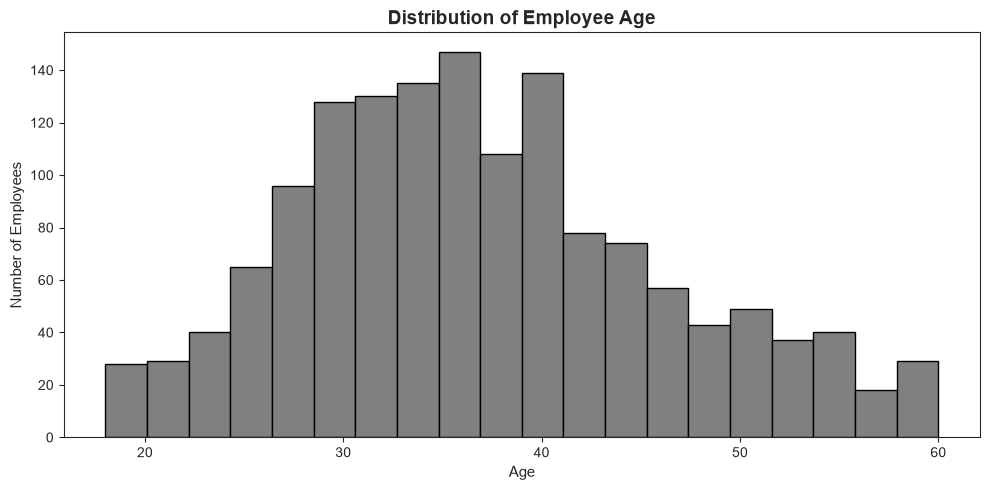

In [10]:
sns.set_style('ticks')

plt.figure(figsize=(10, 5))

plt.hist(
    data['Age'],
    bins=20,
    edgecolor='black',
    color='grey'
)

plt.title('Distribution of Employee Age',
          fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Number of Employees', fontsize=11)

plt.tight_layout()
plt.show()

The age distribution appears approximately bell-shaped, with employees concentrated around the mid-30s and a substantial proportion of observations occurring between approximately 30 and 40 years. The distribution does not display an obvious extreme concentration at either end of the observed age range.

### MonthlyIncome Visualization: Histogram 2 - Income distribution

In [11]:
data['MonthlyIncome'].value_counts()

MonthlyIncome
2342    4
6347    3
3452    3
2451    3
2741    3
       ..
2966    1
2571    1
9991    1
5390    1
4404    1
Name: count, Length: 1349, dtype: int64

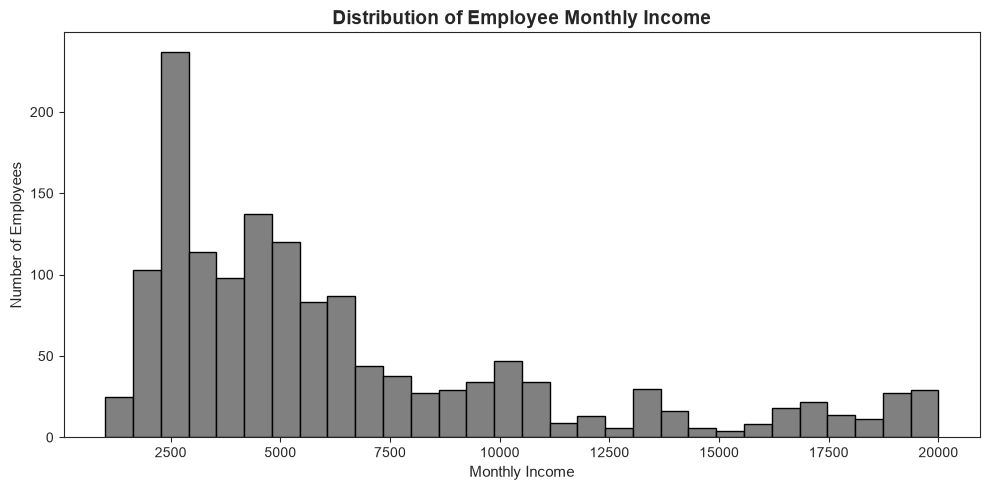

In [12]:
sns.set_style('ticks')

plt.figure(figsize=(10, 5))

plt.hist(
    data['MonthlyIncome'],
    bins=30,
    edgecolor='black',
    color='grey'
)

plt.title('Distribution of Employee Monthly Income',
          fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income', fontsize=11)
plt.ylabel('Number of Employees', fontsize=11)

plt.tight_layout()
plt.show()

Monthly income appears right-skewed, with a large proportion of employees concentrated within the lower-to-middle income range and a smaller number of employees receiving substantially higher incomes. The mean monthly income of approximately 6,502.93 is considerably greater than the median of 4,919, which is consistent with the presence of a higher-income tail.

### Age + Attrition Visualization: Boxplot 1 - Compare age between attrition groups

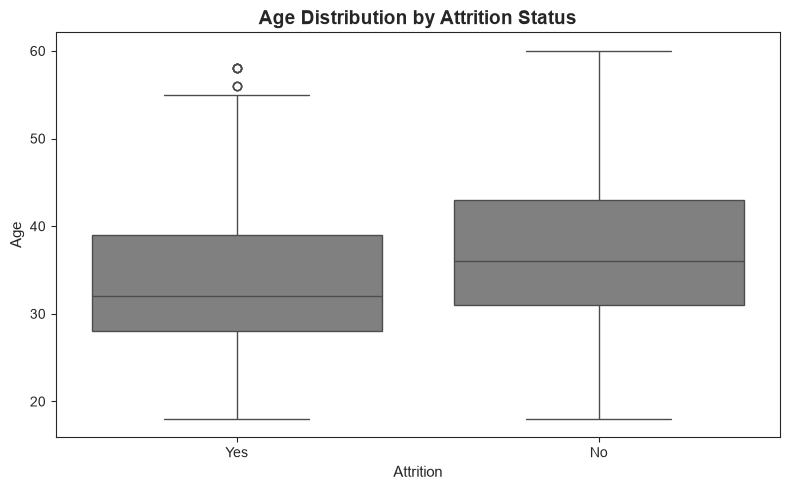

In [13]:
sns.set_style('ticks')

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=data,
    x='Attrition',
    y='Age',
    color='grey'
)

plt.title('Age Distribution by Attrition Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=11)
plt.ylabel('Age', fontsize=11)

plt.tight_layout()
plt.show()

The boxplot provides a visual comparison of age distributions between employees who remained and those who left. Differences in the median and spread between the two groups may suggest that age is associated with different attrition patterns. However, substantial overlap between the distributions would indicate that age alone does not clearly distinguish the two groups. Further statistical analysis would be required to determine whether any observed difference is statistically significant.

### MonthlyIncome + Attrition Visualization: Boxplot 2 - Compare income between attrition groups

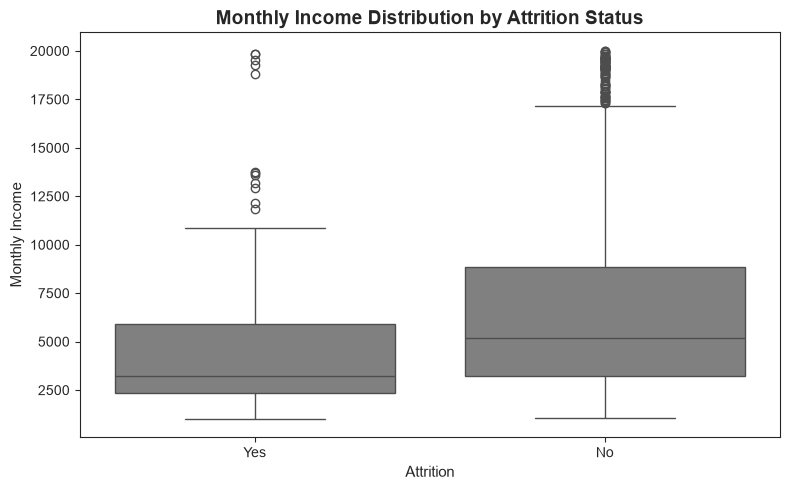

In [14]:
sns.set_style('ticks')

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=data,
    x='Attrition',
    y='MonthlyIncome',
    color= 'grey'
)

plt.title('Monthly Income Distribution by Attrition Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=11)
plt.ylabel('Monthly Income', fontsize=11)

plt.tight_layout()
plt.show()

The boxplot suggests that employees who left the organisation have a lower median monthly income compared with employees who remained. The distributions also show some overlap, indicating that monthly income alone may not fully distinguish between employees who left and those who remained. This suggests a potential association between income and attrition that should be investigated further using statistical analysis.

### Attrition Visualization: Pie-chart - Overall attrition composisiton

In [15]:
data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

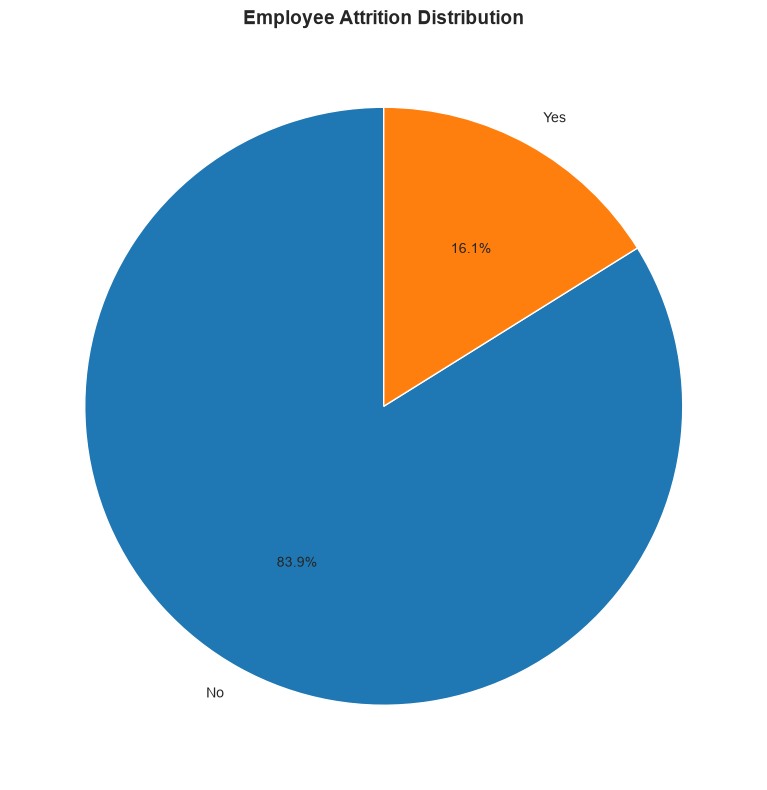

In [16]:
attrition_counts = data['Attrition'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.set_color_codes('deep')
)

plt.title(
    'Employee Attrition Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

The pie chart shows that 1,233 employees (83.9%) remained with the organisation, while 237 employees (16.1%) were recorded as having left. Therefore, the majority of employees in the dataset remained with the organisation, while approximately one-sixth experienced attrition. This provides an overall view of the attrition distribution but does not identify which employee characteristics are associated with employees leaving.

## Attrition Focused Analyses

### Overtime x Attrition

In [17]:
pd.crosstab(
    data['OverTime'], #row index
    data['Attrition'], #Column header
)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [18]:
pd.crosstab(
    data['OverTime'], #row index
    data['Attrition'], #Column header
    normalize = 'index' #Divides each cell by its total rows
)*100 #Converts decimal proportion into percentages

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


### Department x Attrition

In [19]:
pd.crosstab(
    data['Department'],
    data['Attrition'],
)

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [20]:
pd.crosstab(
    data['Department'],
    data['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


### JobRole x Attrition

In [21]:
pd.crosstab(
    data['JobRole'],
    data['Attrition'],
).sort_values(
    by = 'Yes',
    ascending = False
)



Attrition,No,Yes
JobRole,,
Laboratory Technician,197,62
Sales Executive,269,57
Research Scientist,245,47
Sales Representative,50,33
Human Resources,40,12
Manufacturing Director,135,10
Healthcare Representative,122,9
Manager,97,5
Research Director,78,2


In [22]:
jobrole_attrition = pd.crosstab(
    data['JobRole'],
    data['Attrition'],
    normalize='index'
) * 100

jobrole_attrition.sort_values(
    by='Yes',
    ascending=False
)


Attrition,No,Yes
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


### Age, Income and Experience

### Age

In [23]:
data.groupby('Attrition')['Age'].describe()
#Comparing the actual descriptive statistics

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


### Monthly Income

In [ ]:
data.groupby('Attrition')['MonthlyIncome'].describe()

### Total Working Years

In [25]:
data.groupby('Attrition')['TotalWorkingYears'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,11.862936,7.760719,0.0,6.0,10.0,16.0,38.0
Yes,237.0,8.244726,7.169204,0.0,3.0,7.0,10.0,40.0


## Overall Attrition Rate

In [26]:
# 1. Overall attrition rate
data['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [27]:
# 2. Overtime × Attrition
pd.crosstab(data['OverTime'], data['Attrition'], normalize='index') * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


Overtime status shows a notable difference in attrition rates. Employees who work overtime have an attrition rate of 30.53%, compared with 10.44% among employees who do not work overtime. This represents a difference of approximately 20 percentage points and suggests a potential association between overtime and employee attrition. However, this descriptive analysis does not establish that overtime causes attrition, as other employee and organisational factors may contribute to the observed difference.

Overtime appears to be a potentially important factor associated with attrition and warrants further investigation.

In [28]:
# 3. Department × Attrition
pd.crosstab(data['Department'], data['Attrition'], normalize='index') * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


Attrition rates vary across departments. Sales records the highest attrition rate at 20.63%, followed by Human Resources at 19.05%, while Research & Development records the lowest rate at 13.84%. Sales and Human Resources therefore exhibit attrition rates above the overall dataset rate of 16.12%, whereas Research & Development falls below the overall rate. These differences suggest that departmental context may be associated with employee attrition and warrants further investigation.

In [29]:
# 4. Gender × Attrition
pd.crosstab(data['Gender'], data['Attrition'], normalize='index') * 100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


Male employees have a slightly higher attrition rate (17.01%) than female employees (14.80%), representing a difference of approximately 2.21 percentage points. However, the difference is relatively small compared with the larger differences observed for overtime and certain job roles. The results therefore provide limited descriptive evidence of a substantial difference in attrition by gender.

In [30]:
# 5. JobRole × Attrition
pd.crosstab(data['JobRole'], data['Attrition'], normalize='index') * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


Attrition rates vary considerably across job roles. Sales Representatives have the highest attrition rate at 39.76%, followed by Laboratory Technicians at 23.94% and Human Resources employees at 23.08%. In contrast, Research Directors have the lowest attrition rate at 2.50%, followed by Managers at 4.90%. The substantial variation across job roles suggests that occupational role may be an important factor associated with attrition. However, the observed differences may also reflect other characteristics associated with particular roles and should therefore be investigated further before drawing causal conclusions.

In [31]:
# 6. Age × Attrition
data.groupby('Attrition')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


Employees who experienced attrition were generally younger than those who remained. The mean age of employees who left was approximately 33.61 years compared with 37.56 years among employees who remained, while the median ages were 32 and 36 years respectively. This suggests a potential association between younger age and employee attrition. However, the distributions overlap, indicating that age alone does not determine whether an employee leaves the organisation.

In [32]:
# 7. MonthlyIncome × Attrition
data.groupby('Attrition')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


Employees who experienced attrition generally had lower monthly incomes than those who remained. The mean monthly income of employees who left was 4,787.09, compared with 6,832.74 among employees who remained. The median income was also lower among employees who left, at 3,202 compared with 5,204. This suggests a potential association between lower monthly income and employee attrition. However, substantial variation exists within both groups, meaning income alone cannot explain employee attrition.

In [33]:
data.groupby('Attrition')['TotalWorkingYears'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,11.862936,7.760719,0.0,6.0,10.0,16.0,38.0
Yes,237.0,8.244726,7.169204,0.0,3.0,7.0,10.0,40.0


Employees who experienced attrition generally had fewer total working years than those who remained. The mean total working experience was 8.24 years among employees who left compared with 11.86 years among those who remained, while the median was 7 years compared with 10 years respectively. This suggests a potential association between lower work experience and employee attrition. Further analysis would be required to determine whether this relationship remains after considering other factors such as age, job role, income, and overtime.